In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, DeepDataLoaderManager, BaseLineDataLoaderManager, GraphDataLoaderManager

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )
# baselinedata            = BaseLineDataLoaderManager(data_orchestrator)
# graphdata                = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()

In [4]:
final = data_orchestrator.data_final.data

final[final['test']]['timestamp'].min()

Timestamp('2019-06-24 00:00:00')


==                  spatialgnn                  ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 001 train loss: 0.9403, val loss: 1.7447 ✓ (new best)
trained ✓


Forecasting train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 363/363 [00:00<00:00, 652.36it/s]


Huge warning. min date found is more than 6 days away from min date from epiconfig
Huge warning. max date found is more than 6 days away from max date from epiconfig
Train loss: 0.8127
forecasted ✓


SimpleGCNModel(name='spatialgnn')

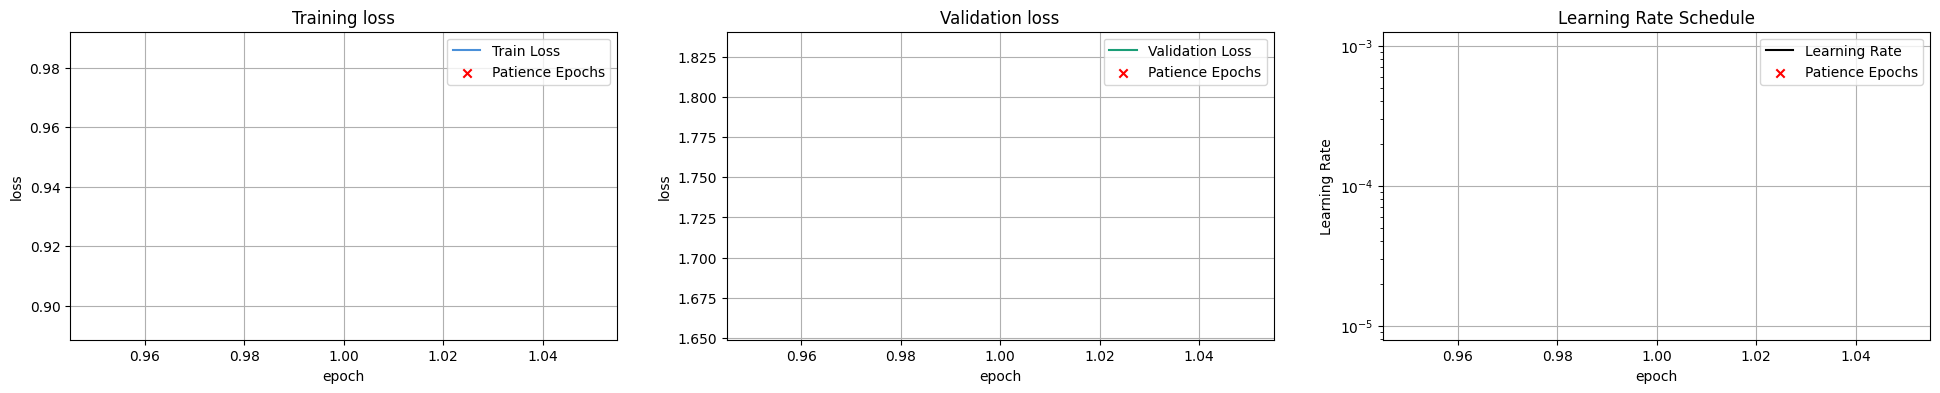

In [134]:
from src.models import SimpleGCNModel

lstm = SimpleGCNModel(graphdata,verbose = 2)
lstm.set_model_hparams()
lstm.set_global_hparams(lr = 0.0001, n_epochs=1)
lstm.train()
lstm.forecast('train')

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 630.51it/s]


Huge warning. min date found is more than 6 days away from min date from epiconfig
Huge warning. max date found is more than 6 days away from max date from epiconfig
Test loss: 2.0428
forecasted ✓


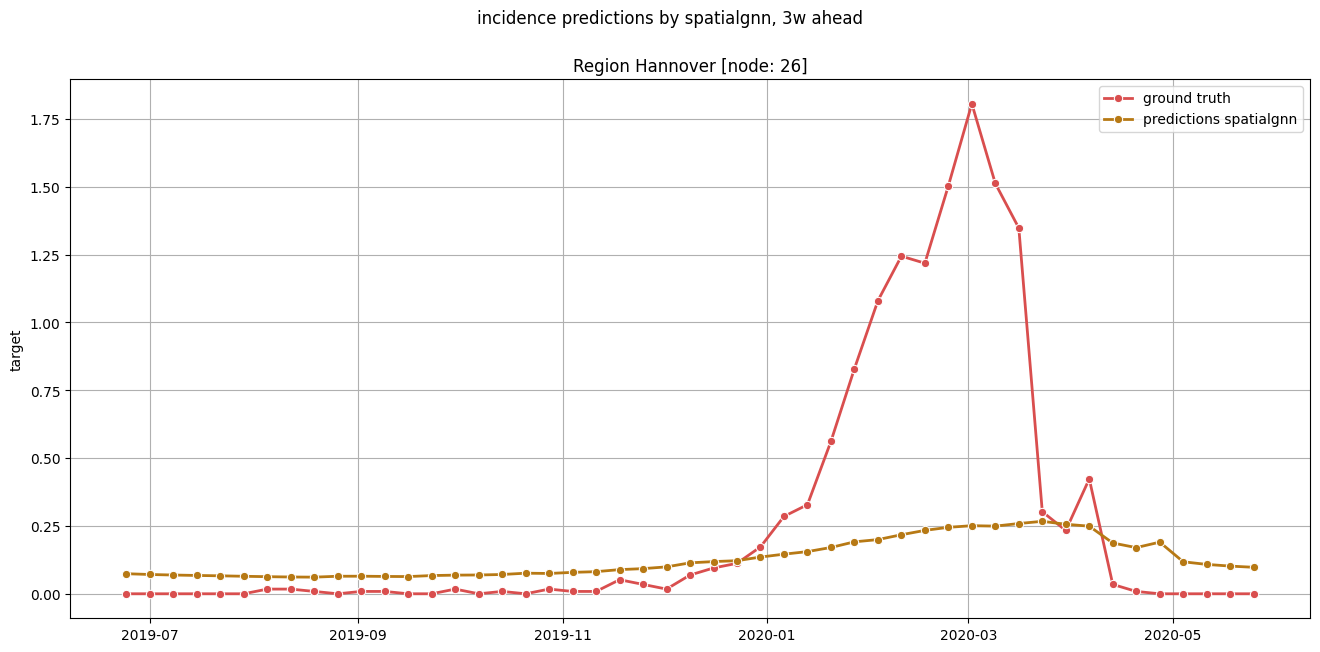

In [135]:
lstm.forecast('test')
lstm.show_forecasts(26,'test').show()

Huge warning. min date found is more than 6 days away from min date from epiconfig
Huge warning. max date found is more than 6 days away from max date from epiconfig
Huge warning. min date found is more than 6 days away from min date from epiconfig
Huge warning. max date found is more than 6 days away from max date from epiconfig
Huge warning. min date found is more than 6 days away from min date from epiconfig
Huge warning. max date found is more than 6 days away from max date from epiconfig


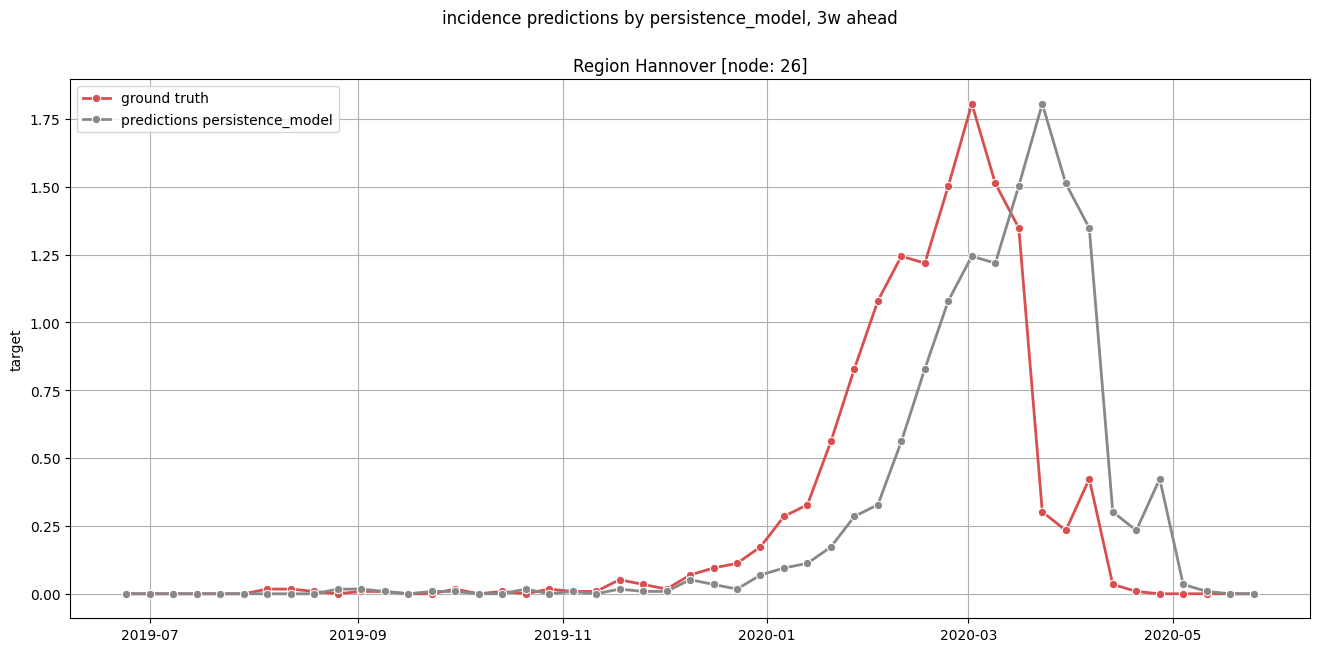

In [137]:
from src.models import PersistenceModel

ps = PersistenceModel(baselinedata)
ps.forecast()
ps.forecast('train')
ps.forecast('val')
ps.show_forecasts(26,'test').show()

In [ ]:
from dataclasses import dataclass 
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from typing import Dict
import pandas as pd

class TemporalError(Exception):
    def __init__(self, message: str):
        super().__init__(f'Invalid EpiDataTemporalSummary: {message}')

def convert_to_next_monday(date: datetime, day_int = 0) -> datetime:
    """returns datetime object thats just shifted to the next version of day int where 0 means Monday"""

    if date.weekday() != day_int:
        days_ahead = (day_int - date.weekday()) % 7
        if days_ahead == 0:  # If we want same day, go to next week
            days_ahead = 7
        shifted_date = date + timedelta(days=days_ahead)
        return shifted_date
    else:
        return date

def convert_to_month_start(date: datetime) -> datetime:
    """Convert date to first day of the month"""
    return datetime(date.year, date.month, 1)

class EpiDataTemporalSummary:
    
    def __init__(self, 
                 temporal_frequency: str,
                 min_date:           str,
                 max_date:           str,
                 split_trainval_date:str,
                 split_valtest_date: str,

                 horizon_size:       int,
                 horizon_leadtime:   int,
                 num_lags:           int, 
                 sequence_length:    int
                 ):
        
        self.temporal_frequency     = temporal_frequency

        # input
        self.min_date                = datetime.strptime(min_date, "%Y-%m-%d") 
        self.max_date                = datetime.strptime(max_date, "%Y-%m-%d") 
        self.split_trainval_date     = datetime.strptime(split_trainval_date, "%Y-%m-%d") 
        self.split_valtest_date      = datetime.strptime(split_valtest_date, "%Y-%m-%d")                         

        self.horizon_size            = horizon_size        
        self.horizon_leadtime        = horizon_leadtime
        self.num_lags                = num_lags 
        self.sequence_length         = sequence_length

        # resample: for weeks > mondays
        self._resample()

        # extend time window for dataloading
        self._set_extended_timepoints()
        self._set_forwarded_timestamps()

        # set forward-timestamps
        self._validate_dates_order()
        self._validate_timepoints()

    def _resample(self):
        """Align dates to temporal frequency (Mondays for weekly, 1st for monthly)"""
        if self.temporal_frequency == 'w':
            self.min_date = convert_to_next_monday(self.min_date)
            self.split_trainval_date = convert_to_next_monday(self.split_trainval_date)
            self.split_valtest_date = convert_to_next_monday(self.split_valtest_date)
            self.max_date = convert_to_next_monday(self.max_date)
        elif self.temporal_frequency == 'm':
            self.min_date = convert_to_month_start(self.min_date)
            self.split_trainval_date = convert_to_month_start(self.split_trainval_date)
            self.split_valtest_date = convert_to_month_start(self.split_valtest_date)
            self.max_date = convert_to_month_start(self.max_date)

    def _set_extended_timepoints(self):
        # lookback periods for lags:
        self.lookback_periods = (self.num_lags - 1 )+ (self.sequence_length - 1)
        self.forward_periods  = self.horizon_leadtime + (self.horizon_size - 1)

        self.min_date_extended = self._shift(self.min_date, -self.lookback_periods)
        self.max_date_extended = self._shift(self.max_date,  self.forward_periods)

    def _set_forwarded_timestamps(self):
        # Calculate target splits (shifted forward by horizon)
        self.split_trainval_fwd = self._shift(self.split_trainval_date, self.horizon_leadtime)
        self.split_valtest_fwd  = self._shift(self.split_valtest_date, self.horizon_leadtime)        

    def _shift(self, date: datetime, steps: int) -> datetime:
        """Shift date by steps (positive=forward, negative=backward)"""
        if self.temporal_frequency == 'd':
            return date + timedelta(days=steps)
        elif self.temporal_frequency == 'w':
            return date + timedelta(weeks=steps)
        elif self.temporal_frequency == 'm':
            return date + relativedelta(months=steps)
        else:
            raise TemporalError(f"Unknown frequency: {self.temporal_frequency}")

    def _validate_dates_order(self):
        if not self.min_date < self.split_trainval_date < self.split_valtest_date < self.max_date:
            raise TemporalError('Incorrect order of date-values')

    def _validate_timepoints(self):
        pass

    def _set_dataset_dates(self):
        """Calculate date ranges for each split"""
        # Calculate one-step delta
        if self.temporal_frequency == 'd':
            delta = timedelta(days=1)
        elif self.temporal_frequency == 'w':
            delta = timedelta(weeks=1)
        elif self.temporal_frequency == 'm':
            delta = relativedelta(months=1)
        else:
            raise TemporalError(f"Unknown frequency: {self.temporal_frequency}")

        # Calculate max dates (one step before next split)
        max_train = self.split_trainval_date - delta
        max_val = self.split_valtest_date - delta

        self.dataset_dates = {
            'train': {'min': self.min_date, 'max': max_train},
            'val': {'min': self.split_trainval_date, 'max': max_val},
            'test': {'min': self.split_valtest_date, 'max': self.max_date},
        }

    # Getter methods for integration
    def get_extended_dates(self) -> Dict[str, pd.Timestamp]:
        """Get extended min/max dates for initial data loading"""
        return {
            'min': pd.Timestamp(self.min_date_extended),
            'max': pd.Timestamp(self.max_date_extended)
        }
    
    def get_input_splits(self) -> Dict[str, pd.Timestamp]:
        """Get INPUT split timestamps for creating train/val/test columns"""
        return {
            'trainval': pd.Timestamp(self.split_trainval_date),
            'valtest': pd.Timestamp(self.split_valtest_date)
        }
    
    def get_target_splits(self) -> Dict[str, pd.Timestamp]:
        """Get TARGET split timestamps (for reference/plotting)"""
        return {
            'trainval': pd.Timestamp(self.split_trainval_fwd),
            'valtest': pd.Timestamp(self.split_valtest_fwd)
        }    

In [ ]:
ts = EpiDataTemporalSummary(config.temporal_frequency,
                            str(config.min_date.date()), 
                            str(config.max_date.date()),
                            config.split_trainval,
                            config.split_valtest,
                            config.horizon_size,
                            config.horizon_leadtime,
                            config.lag_num,
                            config.sequence_length)

In [199]:
ts.get_extended_dates()

{'min': Timestamp('2011-06-20 00:00:00'),
 'max': Timestamp('2020-06-22 00:00:00')}